# J05 — Écoulement non saturé permanent et introduction à HYDRUS-1D

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 5 : fonctions hydrauliques, profils permanents, lecture d'un projet HYDRUS-1D, infiltromètre à disque*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les projets HYDRUS-1D de référence sont dans `../../hydrus/` et se lisent avec le module `hydrus_io.py` (dossier `notebooks/`).
Unités du cours : **cm** et **jours** ; flux **positifs vers le haut** (convention HYDRUS-1D) ; profondeurs négatives.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, integrate
from hydrus_io import read_tlevel, read_nod_inf, read_obs_node, read_balance, read_run_inf

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
HYD = "../../hydrus"

# Sols de Carsel & Parrish (1988) : thr, ths, alpha (1/cm), n, Ks (cm/j), l
SOLS = {
    "sable":         [0.045, 0.430, 0.145, 2.68, 712.8, 0.5],
    "loam sableux":  [0.065, 0.410, 0.075, 1.89, 106.1, 0.5],
    "loam":          [0.078, 0.430, 0.036, 1.56, 24.96, 0.5],
    "loam limoneux": [0.067, 0.450, 0.020, 1.41, 10.80, 0.5],
    "argile":        [0.068, 0.380, 0.008, 1.09, 4.80, 0.5],
}

## Exercice 1 — Fonctions hydrauliques de Mualem–van Genuchten  *(≈ 15 min)*

1. Écrire `vg_theta(h, p)`, `vg_K(h, p)` et `vg_C(h, p)` (vectorisées, `p = [thr, ths, alpha, n, Ks, l]`) :
   $S_e = [1+(\alpha|h|)^n]^{-m}$, $m = 1-1/n$ ; $\theta = \theta_r + (\theta_s-\theta_r)S_e$ ;
   $K = K_s S_e^{l}[1-(1-S_e^{1/m})^m]^2$ ; $C = (\theta_s-\theta_r)\,\alpha n m (\alpha|h|)^{n-1}[1+(\alpha|h|)^n]^{-m-1}$ (et 0 pour $h \ge 0$).
2. Tracer $K(h)$ et $C(h)$ en fonction de $|h|$ (échelles log-log) pour le sable, le loam et l'argile, puis $D(\theta) = K/C$ (échelle log en $y$).
3. Calculer la longueur capillaire macroscopique $\lambda_c = K_s^{-1}\int_{-\infty}^{0} K(h)\,dh$ pour les cinq sols
   (`integrate.quad` avec des points de rupture, ou trapèzes sur une grille logarithmique) et $\alpha_G = 1/\lambda_c$.
   Vérifier le loam : $K(-50) \approx 0{,}258$ cm/j, $K(-500) \approx 1{,}7\times10^{-4}$ cm/j, $\lambda_c \approx 6{,}9$ cm.

loam : K(-50) = 0.2577 cm/j ; K(-500) = 1.707e-04 cm/j ; theta(-50) = 0.302


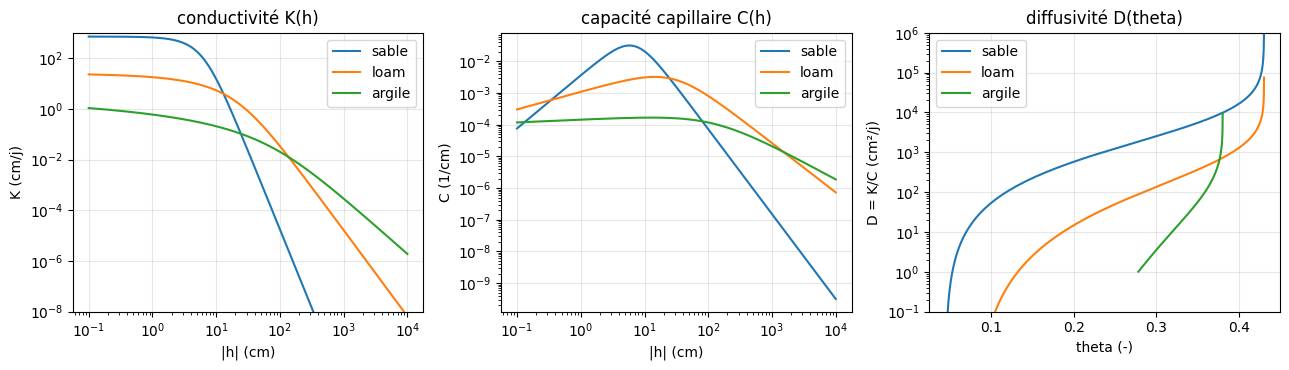

,lambda_c_quad,lambda_c_trapz,alpha_G,theta_100,K_100
sable,3.8080,3.8081,0.2626,0.0493,0.0000
loam sableux,4.9666,4.9666,0.2013,0.1218,0.0046
loam,6.9203,6.9205,0.1445,0.2421,0.0339
loam limoneux,8.9515,8.9520,0.1117,0.3297,0.0704
argile,2.4462,2.4526,0.4088,0.3654,0.0202


In [2]:
def vg_theta(h, p):
    """Teneur en eau (van Genuchten 1980)."""
    thr, ths, a, n, Ks, l = p
    m = 1 - 1 / n
    h = np.asarray(h, float)
    Se = np.where(h < 0, (1 + (a * np.abs(h))**n)**(-m), 1.0)
    return thr + (ths - thr) * Se

def vg_K(h, p):
    """Conductivité hydraulique (Mualem–van Genuchten)."""
    thr, ths, a, n, Ks, l = p
    m = 1 - 1 / n
    h = np.asarray(h, float)
    Se = np.where(h < 0, (1 + (a * np.abs(h))**n)**(-m), 1.0)
    return Ks * Se**l * (1 - (1 - Se**(1 / m))**m)**2

def vg_C(h, p):
    """Capacité capillaire C = dtheta/dh (1/cm)."""
    thr, ths, a, n, Ks, l = p
    m = 1 - 1 / n
    h = np.asarray(h, float)
    ah = a * np.abs(h)
    return np.where(h < 0, (ths - thr) * a * n * m * ah**(n - 1) * (1 + ah**n)**(-m - 1), 0.0)

p = SOLS["loam"]
print(f"loam : K(-50) = {vg_K(-50, p):.4f} cm/j ; K(-500) = {vg_K(-500, p):.3e} cm/j ; theta(-50) = {vg_theta(-50, p):.3f}")

# 2. tracés
hh = -np.logspace(-1, 4, 300)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for nm in ["sable", "loam", "argile"]:
    p = SOLS[nm]
    ax[0].loglog(-hh, vg_K(hh, p), label=nm)
    ax[1].loglog(-hh, vg_C(hh, p), label=nm)
    ax[2].semilogy(vg_theta(hh, p), vg_K(hh, p) / vg_C(hh, p), label=nm)
ax[0].set(xlabel="|h| (cm)", ylabel="K (cm/j)", ylim=(1e-8, 1e3), title="conductivité K(h)")
ax[1].set(xlabel="|h| (cm)", ylabel="C (1/cm)", title="capacité capillaire C(h)")
ax[2].set(xlabel="theta (-)", ylabel="D = K/C (cm²/j)", ylim=(1e-1, 1e6), title="diffusivité D(theta)")
for a in ax: a.legend()
plt.tight_layout(); plt.show()

# 3. longueur capillaire macroscopique
def lambda_c(p):
    """lambda_c = int_{-inf}^0 K(h) dh / Ks (cm) — quadrature avec points de rupture (K varie sur 10 ordres)."""
    val, err = integrate.quad(lambda h: vg_K(h, p) / p[4], -1e4, 0, limit=400, points=[-1000, -100, -10, -1])
    return val

# vérification par trapèzes sur une grille logarithmique de |h| (la contribution de |h| > 1e4 est négligeable)
def lambda_c_trapz(p, hmin=1e-2, hmax=1e4, n=2000):
    habs = np.logspace(np.log10(hmin), np.log10(hmax), n)
    return np.trapezoid(vg_K(-habs, p) / p[4], habs) + hmin   # + segment [0, hmin] où K ≈ Ks

res = pd.DataFrame({nm: dict(lambda_c_quad=lambda_c(p), lambda_c_trapz=lambda_c_trapz(p), alpha_G=1 / lambda_c(p),
                             theta_100=float(vg_theta(-100, p)), K_100=float(vg_K(-100, p)))
                    for nm, p in SOLS.items()}).T
display(res.round(4))

**Commentaire (instructeur).** $K$ chute de 8 à 10 ordres de grandeur entre la saturation et $|h| = 10^4$ cm ; les courbes se croisent vers $|h| \approx 30$–100 cm :
au-delà, le sable est moins conducteur que l'argile. $\lambda_c$ croît du sable (3,8 cm) au loam limoneux (9 cm) : la capillarité
gagne en importance dans les sols fins. La valeur MvG de l'argile ($n = 1{,}09$) est peu réaliste (queue de $K$ très longue, $K_r$
non intégrable en pratique) : c'est une limite connue du modèle pour $n < 1{,}2$.

## Exercice 2 — Profils permanents au-dessus d'une nappe et évaporation maximale  *(≈ 20 min)*

En régime permanent le flux $q$ est constant et $\dfrac{dh}{dz} = -1 - \dfrac{q}{K(h)}$ ($z$ vers le haut, $q > 0$ vers le haut).

1. Écrire `profil_permanent(q, p, L=100)` qui intègre cette EDO avec `integrate.solve_ivp` depuis la nappe ($h = 0$ à $z = -L$)
   jusqu'à la surface ($z = 0$), pour le loam et $q = -1$ cm/j (infiltration) puis $q = +0{,}03$ cm/j (évaporation).
   Prévoir un événement terminal si $h < -10^4$ cm (le flux ne peut pas être maintenu).
2. Lire `NOD_INF.OUT` des projets `J05_permanent_nappe_infiltration` et `J05_permanent_nappe_evaporation` (`read_nod_inf`),
   extraire le profil à $t = 200$ j et le superposer à votre intégration ; calculer l'écart RMS sur $h$ et $h$ en surface
   (attendu : $\approx -28{,}6$ cm par intégration, $-28{,}9$ cm dans HYDRUS pour l'infiltration).
3. Évaporation maximale : la profondeur de nappe maximale compatible avec un flux $q$ est
   $L_{max}(q) = \int_{-\infty}^{0} \dfrac{dh}{1 + q/K(h)}$ (Gardner 1958). Écrire `L_max(q, p)` (quadrature) puis
   `e_max(p, L)` (`optimize.brentq` sur $L_{max}(q) - L$). Calculer $e_{max}$ du loam pour $L = 100$ cm (attendu $\approx 0{,}054$ cm/j)
   et tracer $e_{max}(L)$ pour $L$ de 30 à 300 cm pour le sable, le loam et le loam limoneux (échelles log).

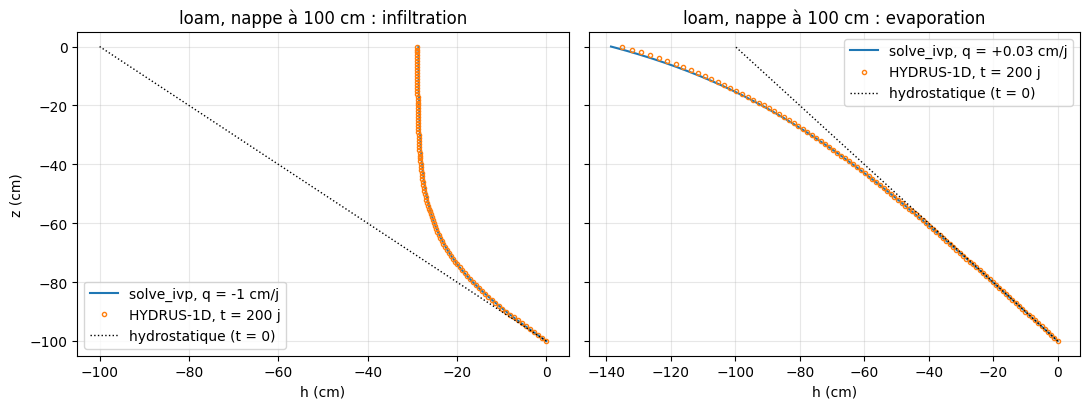

,cas,q,h_surface_python,h_surface_hydrus,RMS_h
0,infiltration,-1.00,-28.620,-28.904,0.241
1,evaporation,0.03,-138.553,-135.182,0.846


e_max du loam, nappe à 100 cm : 0.0545 cm/j
L_max pour q = 0.01, 0.03, 0.05, 0.10 cm/j : [170.6, 121.1, 102.8, 81.8]


,sable,loam,loam limoneux
L (cm),,,
30,3.85e-02,1.41e+00,1.45e+00
50,1.68e-03,4.03e-01,5.61e-01
70,2.10e-04,1.58e-01,2.75e-01
100,2.30e-05,5.45e-02,1.20e-01
150,1.87e-06,1.52e-02,4.27e-02
200,3.14e-07,5.95e-03,1.96e-02
300,2.56e-08,1.56e-03,6.29e-03


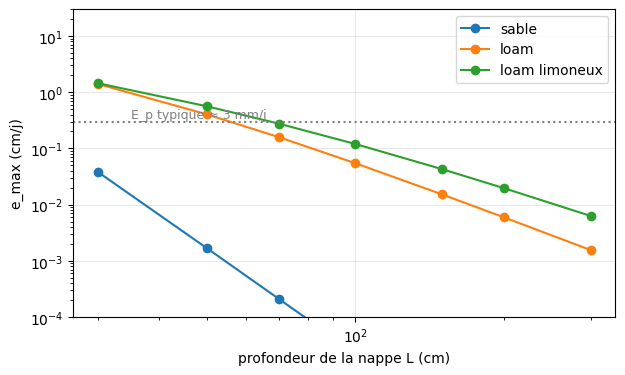

sable          : e_max ~ L^-6.2 entre 70 et 200 cm
loam           : e_max ~ L^-3.1 entre 70 et 200 cm
loam limoneux  : e_max ~ L^-2.5 entre 70 et 200 cm


In [3]:
def profil_permanent(q, p, L=100.0):
    """Intègre dh/dz = -1 - q/K(h) depuis la nappe (h = 0 en z = -L) vers la surface. q > 0 vers le haut."""
    f = lambda z, h: [-1.0 - q / vg_K(h[0], p)]
    ev = lambda z, h: h[0] + 1e4        # arrêt si h < -1e4 cm : le flux ne peut pas être entretenu
    ev.terminal = True
    sol = integrate.solve_ivp(f, [-L, 0.0], [0.0], max_step=0.5, rtol=1e-8, atol=1e-10, events=ev)
    return sol.t, sol.y[0]

p = SOLS["loam"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
resultats = []
for k, (tag, q) in enumerate([("infiltration", -1.0), ("evaporation", 0.03)]):
    z, h = profil_permanent(q, p)
    nod = read_nod_inf(f"{HYD}/J05_permanent_nappe_{tag}")
    prof = nod[max(nod)]                                 # profil au dernier temps d'impression (200 j)
    h_hyd = np.interp(prof["Depth"].to_numpy()[::-1], z, h)[::-1]   # intégration interpolée aux nœuds HYDRUS
    rms = np.sqrt(np.mean((h_hyd - prof["Head"].to_numpy())**2))
    resultats.append(dict(cas=tag, q=q, h_surface_python=h[-1], h_surface_hydrus=prof["Head"].iloc[0], RMS_h=rms))
    ax[k].plot(h, z, label=f"solve_ivp, q = {q:+g} cm/j")
    ax[k].plot(prof["Head"], prof["Depth"], "o", ms=3, mfc="none", label="HYDRUS-1D, t = 200 j")
    ax[k].plot(-100 - np.linspace(-100, 0, 2), np.linspace(-100, 0, 2), "k:", lw=1, label="hydrostatique (t = 0)")
    ax[k].set(xlabel="h (cm)", title=f"loam, nappe à 100 cm : {tag}")
    ax[k].legend()
ax[0].set_ylabel("z (cm)")
plt.tight_layout(); plt.show()
display(pd.DataFrame(resultats).round(3))

# 3. évaporation maximale (Gardner 1958)
def L_max(q, p):
    """Profondeur maximale de nappe capable d'entretenir le flux q (h -> -inf en surface)."""
    with np.errstate(divide="ignore"):
        return integrate.quad(lambda h: 1.0 / (1.0 + q / vg_K(h, p)), -1e7, 0, limit=500,
                              points=[-1e5, -1e4, -1e3, -100, -10, -1])[0]

def e_max(p, L):
    """Évaporation maximale (cm/j) depuis une nappe à la profondeur L (cm)."""
    return optimize.brentq(lambda q: L_max(q, p) - L, 1e-12, p[4], xtol=1e-9, rtol=1e-8)

print(f"e_max du loam, nappe à 100 cm : {e_max(SOLS['loam'], 100):.4f} cm/j")
print("L_max pour q = 0.01, 0.03, 0.05, 0.10 cm/j :", [round(L_max(q, SOLS['loam']), 1) for q in (0.01, 0.03, 0.05, 0.10)])

Ls = np.array([30, 50, 70, 100, 150, 200, 300])
tab = pd.DataFrame({nm: [e_max(SOLS[nm], L) for L in Ls] for nm in ["sable", "loam", "loam limoneux"]}, index=Ls)
tab.index.name = "L (cm)"
display(tab.map(lambda v: f"{v:.2e}"))
fig, ax = plt.subplots()
for nm in tab.columns:
    ax.loglog(Ls, tab[nm].clip(lower=1e-6), "o-", label=nm)
ax.axhline(0.3, ls=":", color="gray"); ax.text(35, 0.35, "E_p typique ≈ 3 mm/j", fontsize=9, color="gray")
ax.set(xlabel="profondeur de la nappe L (cm)", ylabel="e_max (cm/j)", ylim=(1e-4, 30)); ax.legend(); plt.show()

# pente log-log : e_max ~ L^-n (Gardner)
for nm in tab.columns:
    n_fit = -np.polyfit(np.log(Ls[2:6]), np.log(tab[nm].to_numpy()[2:6]), 1)[0]
    print(f"{nm:14s} : e_max ~ L^-{n_fit:.1f} entre 70 et 200 cm")

**Commentaire (instructeur).** Pour l'infiltration, le profil devient vertical (gradient unitaire) dès 40–50 cm au-dessus de la nappe, à $h \approx -28{,}6$ cm
tel que $K(h) = 1$ cm/j ; HYDRUS donne $-28{,}9$ cm (moyenne arithmétique de $K$ entre nœuds près de la nappe). Pour l'évaporation à
0,03 cm/j la surface est à $-135$ cm. L'évaporation maximale du loam pour une nappe à 1 m ($\approx 0{,}054$ cm/j) est bien
inférieure à une demande de 3 mm/j : l'évaporation est limitée par le sol. La décroissance de $e_{max}$ suit une loi de puissance
$L^{-n}$ avec $n \approx 3$ pour le loam, comme prévu par Gardner (1958).

## Exercice 3 — Lecture d'un projet HYDRUS-1D : convergence vers le régime permanent  *(≈ 15 min)*

Les deux projets `J05_permanent_nappe_*` partent d'un profil hydrostatique ($h = -100 - z$, $H = -100$ cm) et imposent un flux constant
en surface (−1 cm/j ou +0,03 cm/j) avec une nappe fixe ($h = 0$) au bas d'une colonne de loam de 100 cm, pendant 200 j.

1. Lire `T_LEVEL.OUT` (`read_tlevel`) et tracer `vTop`, `vBot` (flux en surface et au bas, > 0 vers le haut) et `hTop`
   en fonction du temps pour les deux projets. Déterminer $t_{99}$, premier instant où $|$`vBot` − `vTop`$| < 1$ % de $|q|$.
2. Lire `RUN_INF.OUT` (`read_run_inf`) : tracer $\Delta t$ en fonction du temps (échelle log), l'histogramme du nombre
   d'itérations par pas ; compter les pas et les itérations totales.
3. Lire `BALANCE.OUT` (`read_balance`) : erreur relative maximale `WatBalR` (%) et évolution du stock `W-volume` ;
   vérifier que la variation de stock entre 0 et 200 j est cohérente avec `sum(vTop)` − `sum(vBot)` de `T_LEVEL.OUT`
   (attention aux signes : $\Delta W = \int (q_{bas} - q_{haut})\,dt$ avec $q > 0$ vers le haut).

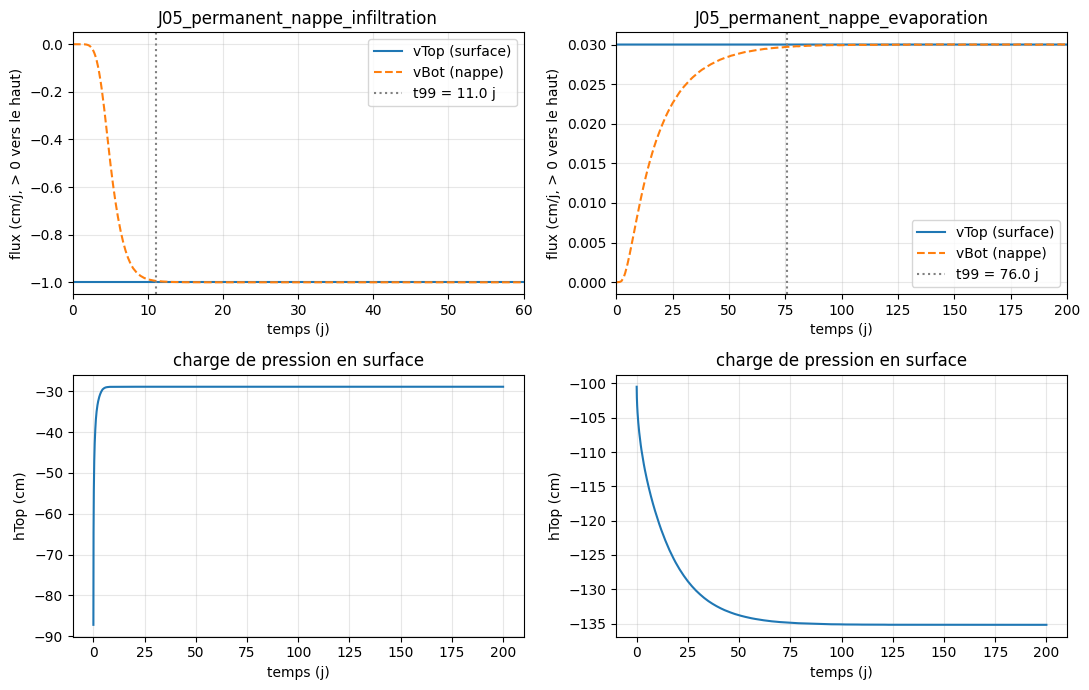

cas,infiltration,evaporation
q,-1.000000,0.030000
t99_j,11.000000,76.000000
hTop_final,-28.904000,-135.180000
n_pas,266.000000,217.000000
iter_total,675.000000,435.000000
iter_moy,2.537594,2.004608
dt_min,0.010000,0.010000
dt_max,1.000000,1.000000
WatBalR_max_pct,0.000000,0.009000
W0,31.631000,31.631000


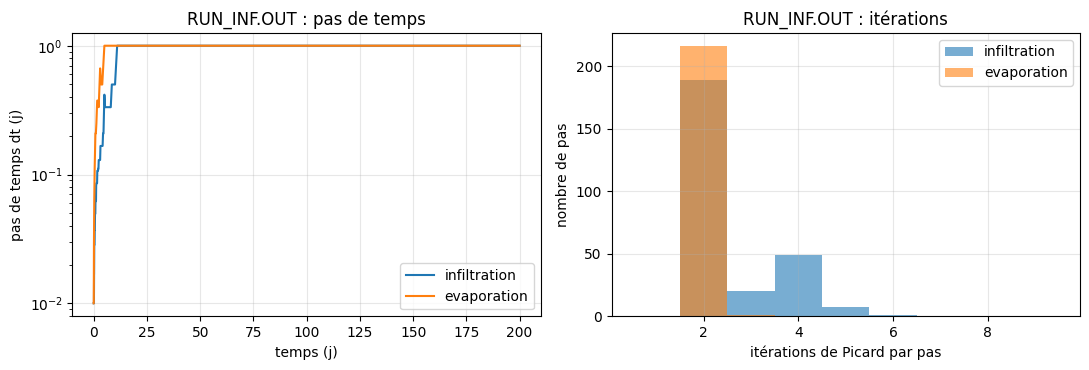

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
bilans = []
for k, tag in enumerate(["infiltration", "evaporation"]):
    P = f"{HYD}/J05_permanent_nappe_{tag}"
    tl = read_tlevel(P)
    q = tl["rTop"].iloc[-1]
    ecart = (tl["vBot"] - tl["vTop"]).abs()
    t99 = tl.index[np.argmax(ecart.to_numpy() < 0.01 * abs(q))]
    ax[0, k].plot(tl.index, tl["vTop"], label="vTop (surface)")
    ax[0, k].plot(tl.index, tl["vBot"], "--", label="vBot (nappe)")
    ax[0, k].axvline(t99, color="gray", ls=":", label=f"t99 = {t99:.1f} j")
    ax[0, k].set(xlabel="temps (j)", ylabel="flux (cm/j, > 0 vers le haut)", title=f"J05_permanent_nappe_{tag}")
    ax[0, k].set_xlim(0, 60 if tag == "infiltration" else 200); ax[0, k].legend()
    ax[1, k].plot(tl.index, tl["hTop"]); ax[1, k].set(xlabel="temps (j)", ylabel="hTop (cm)", title="charge de pression en surface")
    # 2. informations d'exécution
    ri = read_run_inf(P)
    # 3. bilan de masse
    bal = read_balance(P)
    dW_balance = bal["W-volume"].iloc[-1] - bal["W-volume"].iloc[0]
    dW_flux = -(tl["sum(vTop)"].iloc[-1] - tl["sum(vBot)"].iloc[-1])    # dW/dt = q_bas - q_haut
    bilans.append(dict(cas=tag, q=q, t99_j=t99, hTop_final=tl["hTop"].iloc[-1], n_pas=len(ri), iter_total=int(ri["Iter"].sum()),
                       iter_moy=ri["Iter"].mean(), dt_min=ri["dt"].min(), dt_max=ri["dt"].max(),
                       WatBalR_max_pct=bal["WatBalR"].abs().max(), W0=bal["W-volume"].iloc[0], W200=bal["W-volume"].iloc[-1],
                       dW_balance=dW_balance, dW_flux_TLEVEL=dW_flux))
plt.tight_layout(); plt.show()
display(pd.DataFrame(bilans).set_index("cas").T)

# pas de temps et itérations
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for tag in ["infiltration", "evaporation"]:
    ri = read_run_inf(f"{HYD}/J05_permanent_nappe_{tag}")
    ax[0].semilogy(ri["Time"], ri["dt"], label=tag)
    ax[1].hist(ri["Iter"], bins=np.arange(0.5, 10.5, 1), alpha=0.6, label=tag)
ax[0].set(xlabel="temps (j)", ylabel="pas de temps dt (j)", title="RUN_INF.OUT : pas de temps"); ax[0].legend()
ax[1].set(xlabel="itérations de Picard par pas", ylabel="nombre de pas", title="RUN_INF.OUT : itérations"); ax[1].legend()
plt.tight_layout(); plt.show()

**Commentaire (instructeur).** Le régime permanent (à 1 % près) est atteint en ~11 j pour l'infiltration (l'eau infiltrée traverse un sol déjà humide) mais en
~75 j pour l'évaporation, car la diffusivité du sol qui sèche est très faible. Le pas de temps croît de 0,01 j à 1 j (borné par
l'intervalle d'impression de 20 j et par dtMax), avec 2 à 6 itérations de Picard par pas. L'erreur de bilan `WatBalR` reste
inférieure à 0,01 % et la variation de stock (+5,1 cm en infiltration, −0,6 cm en évaporation) est retrouvée à partir des flux
cumulés de `T_LEVEL.OUT`.

## Exercice 4 — Infiltromètre à disque : Wooding et méthode à deux tensions  *(≈ 10 min)*

`data/J05_infiltrometre.csv` : pour quatre sites (textures indiquées), débits permanents $Q$ (cm³/min) mesurés avec un disque de rayon
$r = 10$ cm aux tensions $h_0 = -3$ cm et $-10$ cm.

Solution de Wooding (1968) avec $K = K_s e^{\alpha_G h}$ : $Q = \pi r^2 K(h_0)\left(1 + \dfrac{4}{\pi r \alpha_G}\right)$.

1. Pour chaque site, estimer $\alpha_G = \ln(Q_1/Q_2)/(h_1 - h_2)$, $\lambda_c = 1/\alpha_G$, puis $K_s$ (convertir $Q$ en cm³/j).
2. Calculer la part du débit due à la capillarité latérale, $4/(\pi r\alpha_G) / (1 + 4/(\pi r\alpha_G))$, à $h_0 = -3$ cm.
3. Comparer $K_s$ et $\lambda_c$ aux valeurs de Carsel & Parrish de la texture (exercice 1) ; commenter les écarts.

,site,texture,r_cm,Q_h3_cm3min,Q_h10_cm3min,alpha_G,lambda_c,Ks,part_capillaire_%,Ks_CarselParrish,lambda_c_MvG,K(-10)_Gardner,K(-10)_MvG
0,A,sable,10.0,63.109,8.708,0.283,3.534,466.212,31.034,712.80,3.808,27.527,15.126
1,B,loam sableux,10.0,24.901,4.931,0.231,4.323,147.366,35.500,106.10,4.967,14.578,13.468
2,C,loam,10.0,8.078,3.474,0.121,8.295,25.853,51.367,24.96,6.920,7.744,5.377
3,D,loam limoneux,10.0,2.704,1.171,0.120,8.364,8.591,51.574,10.80,8.951,2.599,2.637


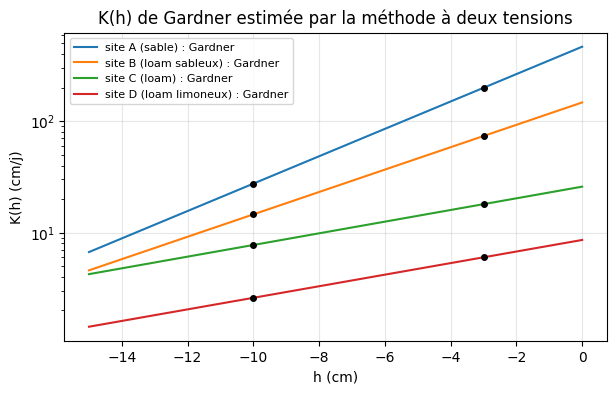

In [5]:
inf = pd.read_csv("data/J05_infiltrometre.csv")
h1, h2 = -3.0, -10.0
Q1 = inf["Q_h3_cm3min"] * 1440      # cm3/j
Q2 = inf["Q_h10_cm3min"] * 1440
r = inf["r_cm"]
inf["alpha_G"] = np.log(Q1 / Q2) / (h1 - h2)
inf["lambda_c"] = 1 / inf["alpha_G"]
geom = 1 + 4 / (np.pi * r * inf["alpha_G"])                      # facteur géométrique de Wooding
inf["Ks"] = Q1 * np.exp(-inf["alpha_G"] * h1) / (np.pi * r**2 * geom)
inf["part_capillaire_%"] = 100 * (geom - 1) / geom
inf["Ks_CarselParrish"] = [SOLS[t][4] for t in inf["texture"]]
inf["lambda_c_MvG"] = [lambda_c(SOLS[t]) for t in inf["texture"]]
inf["K(-10)_Gardner"] = inf["Ks"] * np.exp(inf["alpha_G"] * (-10))
inf["K(-10)_MvG"] = [float(vg_K(-10, SOLS[t])) for t in inf["texture"]]
display(inf.round(3))

fig, ax = plt.subplots()
for _, s in inf.iterrows():
    hh = np.linspace(-15, 0, 50)
    ax.semilogy(hh, s["Ks"] * np.exp(s["alpha_G"] * hh), label=f"site {s['site']} ({s['texture']}) : Gardner")
    ax.plot([h1, h2], [s["Ks"] * np.exp(s["alpha_G"] * h1), s["Ks"] * np.exp(s["alpha_G"] * h2)], "ko", ms=4)
ax.set(xlabel="h (cm)", ylabel="K(h) (cm/j)", title="K(h) de Gardner estimée par la méthode à deux tensions"); ax.legend(fontsize=8)
plt.show()

**Commentaire (instructeur).** Le facteur géométrique $1 + 4/(\pi r \alpha_G)$ vaut 1,4 (sable) à 2,1 (loam limoneux) : négliger la capillarité latérale
surestimerait $K$ de 40 à 110 %. Les $K_s$ « de terrain » diffèrent du catalogue d'un facteur 0,7 à 1,4 (variabilité typique,
souvent bien plus au champ) alors que $\lambda_c$ est retrouvée à ±20 % : la longueur capillaire est une propriété plus stable que $K_s$.
Rappel : ces mesures excluent les macropores ($h_0 < 0$) ; $K_s$ estimée par extrapolation à $h = 0$ est celle de la matrice.

## Exercice 5 — Bonus — solution analytique de Gardner pour l'évaporation maximale  *(≈ facultatif)*

Pour $K = K_s e^{\alpha_G h}$, montrer que $L_{max}(q) = \dfrac{1}{\alpha_G}\ln\!\left(1 + \dfrac{K_s}{q}\right)$ et donc
$e_{max}(L) = \dfrac{K_s}{e^{\alpha_G L} - 1}$. Calculer $e_{max}$ du loam ($K_s = 24{,}96$ cm/j, $\alpha_G = 1/\lambda_c$) pour
$L = 30, 50, 100$ cm et comparer aux valeurs MvG de l'exercice 2. D'où vient l'écart ?

,e_max_Gardner,e_max_MvG
L_cm,,
30,3.313e-01,1.405e+00
50,1.819e-02,4.027e-01
100,1.323e-05,5.447e-02


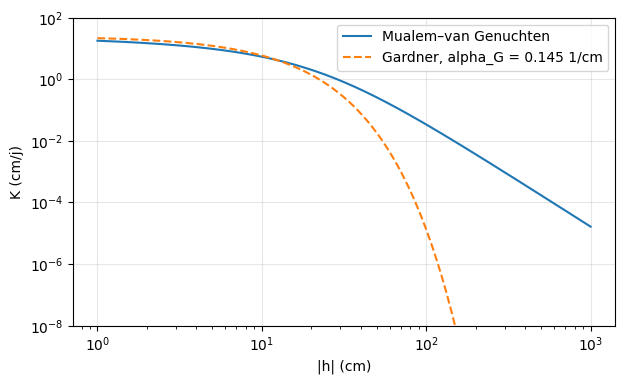

In [6]:
p = SOLS["loam"]
aG = 1 / lambda_c(p)
# L_max = int_{-inf}^0 dh / (1 + (q/Ks) e^{-aG h}) : poser u = e^{aG h} -> L_max = (1/aG) ln(1 + Ks/q)
rows = []
for L in [30, 50, 100]:
    rows.append(dict(L_cm=L, e_max_Gardner=p[4] / (np.exp(aG * L) - 1), e_max_MvG=e_max(p, L)))
display(pd.DataFrame(rows).set_index("L_cm").map(lambda v: f"{v:.3e}"))

# comparaison des deux K(h) sur la gamme utile
hh = -np.logspace(0, 3, 200)
fig, ax = plt.subplots()
ax.loglog(-hh, vg_K(hh, p), label="Mualem–van Genuchten")
ax.loglog(-hh, p[4] * np.exp(aG * hh), "--", label=f"Gardner, alpha_G = {aG:.3f} 1/cm")
ax.set(xlabel="|h| (cm)", ylabel="K (cm/j)", ylim=(1e-8, 1e2)); ax.legend(); plt.show()

**Commentaire (instructeur).** Le modèle exponentiel sous-estime $e_{max}$ de plusieurs ordres de grandeur dès que $L > 50$ cm : sa conductivité décroît
beaucoup plus vite que la loi de puissance de MvG ($K \propto |h|^{-3{,}4}$ pour le loam loin de la saturation), or c'est la
queue de $K(h)$ dans le sol sec qui contrôle la remontée capillaire. Gardner (1958) utilisait d'ailleurs $K = a/(b + |h|^n)$
pour ce problème, pas l'exponentielle.

## Pour aller plus loin

* Reprendre l'exercice 2 avec la nappe à 50 cm et à 150 cm : comment évolue $h$ en surface pour $q = -1$ cm/j ?
* Dans HYDRUS-1D, remplacer le flux imposé de $+0{,}03$ cm/j par $+0{,}06$ cm/j ($> e_{max}$) et observer `RUN_INF.OUT`.
* Réaliser l'essai à trois tensions ($-3$, $-6$, $-10$ cm) et vérifier la linéarité de $\ln Q$ en fonction de $h_0$.